# Experiment: SDPO Recovery Protocol

This notebook implements the full recovery protocol:
- fair checkpoint-policy comparison (`matched` vs `latest`)
- failure localization gates (format/compliance, length drift, SDPO signal utilization)
- 7-desiderata decomposition (with D2/D3 focus)
- 3-run recovery ladder (Run A/B/C config + command templates)
- checkpoint selection and acceptance criteria


In [1]:
# Setup
from __future__ import annotations

from pathlib import Path
from collections import Counter
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    pass

pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 320)


In [2]:
# Config
RUNS = [
    {'label': 'best_ver_ml', 'path': Path('/home/silas/co-scientist-project/runs/2026/2/withA1,A2/2(ml)'), 'is_baseline': True},
    {'label': 'sdpo_27_rich', 'path': Path('/home/silas/co-scientist-project/runs/2026/2/SDPO/27(rich)'), 'is_baseline': False},
    {'label': 'sdpo_27_rich_sanity', 'path': Path('/home/silas/co-scientist-project/runs/2026/2/SDPO/27(rich)(sanity check)'), 'is_baseline': False},
]

BASELINE_LABEL = 'best_ver_ml'
MATCHED_STEP = 106
BASELINE_PRE_STEP = -1
BASELINE_LATEST_PREFERRED_STEP = 214

# Gates from recovery plan
GATE_COMPLIANCE_MIN = 0.97
GATE_FORMAT_MAX = 0.03
GATE_WORD_MEDIAN_LOW = 550
GATE_WORD_MEDIAN_HIGH = 650
GATE_WORD_P90_MAX = 1200
GATE_SDPO_SUCCESS_RATE_MIN = 0.20
GATE_RECOVERED_EVAL_RUBRIC_MIN = 0.67
GATE_D2D3_GAP_MAX_TO_BASELINE = 0.10

PRIMARY_METRIC = "eval_rubric_mean"


In [3]:
# Helpers

def read_jsonl(path: Path | None, max_rows: int | None = None) -> list[dict]:
    if path is None or not path.exists() or not path.is_file():
        return []
    rows = []
    with path.open('r', encoding='utf-8', errors='ignore') as f:
        for i, line in enumerate(f, start=1):
            if max_rows is not None and i > max_rows:
                break
            s = line.strip()
            if not s:
                continue
            try:
                rows.append(json.loads(s))
            except json.JSONDecodeError:
                continue
    return rows


def parse_eval_step(path: Path) -> int | None:
    m = re.search(r'\(([-]?\d+)\)\.jsonl$', path.name)
    if not m:
        return None
    try:
        return int(m.group(1))
    except Exception:
        return None


def list_eval_files(run_dir: Path, stem: str) -> list[Path]:
    eval_dir = run_dir / 'evaluation'
    if not eval_dir.exists():
        return []
    return sorted([p for p in eval_dir.glob(f'{stem}*.jsonl') if p.is_file()])


def select_eval_file(run_dir: Path, stem: str, *, policy: str = 'latest', step: int | None = None, preferred_step: int | None = None) -> Path | None:
    files = list_eval_files(run_dir, stem)
    if not files:
        return None

    by_step = {}
    for p in files:
        s = parse_eval_step(p)
        if s is not None:
            by_step[s] = p

    if step is not None:
        return by_step.get(int(step))

    if preferred_step is not None and int(preferred_step) in by_step:
        return by_step[int(preferred_step)]

    policy = str(policy).lower().strip()
    ranked = []
    for p in files:
        s = parse_eval_step(p)
        ranked.append((p, s if s is not None else -10**9, p.stat().st_mtime))

    if policy == 'earliest':
        ranked.sort(key=lambda x: (x[1], x[2]))
    else:
        ranked.sort(key=lambda x: (x[1], x[2]), reverse=True)

    return ranked[0][0]


def paired_eval_batch_summary(run_dir: Path, eval_log_path: Path | None) -> Path | None:
    if eval_log_path is None:
        return None
    step = parse_eval_step(eval_log_path)
    if step is None:
        return None
    p = run_dir / 'evaluation' / f'eval_batch_summary({step}).jsonl'
    return p if p.exists() else None


def safe_mean(v) -> float:
    s = pd.to_numeric(pd.Series(v), errors='coerce').dropna()
    return float(s.mean()) if len(s) else np.nan


def safe_q(v, q: float) -> float:
    s = pd.to_numeric(pd.Series(v), errors='coerce').dropna()
    return float(s.quantile(q)) if len(s) else np.nan


def eval_metrics_from_logs(eval_log_path: Path | None) -> dict:
    rows = read_jsonl(eval_log_path)
    if not rows:
        return {}
    df = pd.DataFrame(rows)
    out = {
        'eval_log_path': str(eval_log_path),
        'eval_samples': len(df),
    }

    if 'rubric_score' in df:
        out['eval_rubric_mean'] = safe_mean(df['rubric_score'])
    if 'final_reward' in df:
        out['eval_reward_mean'] = safe_mean(df['final_reward'])
    if 'word_count' in df:
        out['eval_word_mean'] = safe_mean(df['word_count'])
        out['eval_word_p50'] = safe_q(df['word_count'], 0.50)
        out['eval_word_p75'] = safe_q(df['word_count'], 0.75)
        out['eval_word_p90'] = safe_q(df['word_count'], 0.90)

    if 'is_compliant' in df:
        comp = pd.to_numeric(df['is_compliant'], errors='coerce')
        out['eval_compliance_rate'] = float(comp.mean())
        out['eval_format_violation_rate'] = float((1.0 - comp).mean())
    elif 'format_penalty' in df:
        fp = pd.to_numeric(df['format_penalty'], errors='coerce')
        out['eval_format_violation_rate'] = float((fp > 1e-12).mean())

    return out


def eval_metrics_from_batch(eval_batch_path: Path | None) -> dict:
    rows = read_jsonl(eval_batch_path)
    if not rows:
        return {}
    df = pd.DataFrame(rows)
    out = {
        'eval_batch_path': str(eval_batch_path),
        'eval_batches': len(df),
    }

    for src, dst in [
        ('samples/generated', 'eval_generated_mean'),
        ('samples/valid', 'eval_valid_mean'),
        ('format_rate', 'eval_format_rate_batch_mean'),
        ('reward/sample_mean_valid', 'eval_reward_batch_mean'),
        ('rubric/sample_mean_valid', 'eval_rubric_batch_valid_mean'),
        ('rubric/sample_mean_all', 'eval_rubric_batch_all_mean'),
        ('length_mean', 'eval_length_mean_batch'),
    ]:
        if src in df.columns:
            out[dst] = safe_mean(df[src])

    return out


def train_batch_phase_metrics(run_dir: Path) -> dict:
    p = run_dir / 'train' / 'batch_summary.jsonl'
    rows = read_jsonl(p)
    if not rows:
        return {}
    df = pd.DataFrame(rows)
    if 'batch_idx' not in df.columns:
        df['batch_idx'] = np.arange(len(df))
    idx_numeric = pd.to_numeric(df['batch_idx'], errors='coerce')
    idx_fallback = pd.Series(np.arange(len(df)), index=df.index, dtype='float64')
    df['batch_idx'] = idx_numeric.where(idx_numeric.notna(), idx_fallback).astype(int)
    df = df.sort_values('batch_idx').reset_index(drop=True)

    n = len(df)
    c1 = max(1, n // 3)
    c2 = max(c1 + 1, 2 * n // 3)
    phases = {
        'early': df.iloc[:c1],
        'mid': df.iloc[c1:c2],
        'late': df.iloc[c2:],
    }

    out = {'train_batch_path': str(p), 'train_batches': n}
    metrics = [
        ('reward/sample_mean_valid', 'reward'),
        ('rubric/sample_mean_valid', 'rubric'),
        ('format_rate', 'format_rate'),
        ('samples/trainability_pass_rate', 'trainability_rate'),
        ('length_mean', 'length_mean'),
        ('length/total_mean', 'length_total_mean'),
        ('sdpo/success_rate_groups', 'sdpo_success_rate_groups'),
        ('sdpo/success_cutoff', 'sdpo_success_cutoff'),
    ]

    for ph, sub in phases.items():
        for src, short in metrics:
            if src in sub.columns:
                out[f'{ph}_{short}'] = safe_mean(sub[src])

    # tail10 snapshot
    tail = df.tail(min(10, len(df)))
    for src, short in metrics:
        if src in tail.columns:
            out[f'tail10_{short}'] = safe_mean(tail[src])

    return out


def train_drop_metrics(run_dir: Path) -> dict:
    p = run_dir / 'train' / 'training_logs.jsonl'
    rows = read_jsonl(p)
    if not rows:
        return {}
    df = pd.DataFrame(rows)
    out = {'train_log_path': str(p), 'train_samples': len(df)}

    if 'drop_reason' in df.columns:
        vc = df['drop_reason'].dropna().astype(str).value_counts()
        out['drop_format_noncompliant'] = int(vc.get('format_noncompliant', 0))
        out['drop_too_short_solution'] = int(vc.get('too_short_solution', 0))
        out['drop_grader_xml_invalid'] = int(vc.get('grader_xml_invalid', 0))
        out['drop_non_solution_too_long'] = int(vc.get('non_solution_too_long', 0))
        out['drop_top5'] = dict(vc.head(5))

    if 'format_failure_subtype' in df.columns:
        vf = df['format_failure_subtype'].dropna().astype(str).value_counts()
        out['format_subtype_top5'] = dict(vf.head(5))

    return out


DES_BLOCK_RE = re.compile(r"<desiderata(?:m)?\b[^>]*num\s*=\s*['\"]?([1-7])['\"]?[^>]*>(.*?)</desiderata(?:m)?>", re.IGNORECASE | re.DOTALL)
LEVEL_RE = re.compile(r'<level>\s*([0-3])\s*</level>', re.IGNORECASE)
ITEM_RE = re.compile(r'<item\b[^>]*>(.*?)</item>', re.IGNORECASE | re.DOTALL)


def parse_desiderata_vec(text: str) -> np.ndarray | None:
    if not isinstance(text, str) or not text.strip():
        return None

    item_vecs = []
    for item in ITEM_RE.findall(text):
        m = {}
        for n_s, body in DES_BLOCK_RE.findall(item):
            lm = LEVEL_RE.search(body)
            if lm:
                n = int(n_s)
                if n not in m:
                    m[n] = int(lm.group(1))
        if len(m) == 7:
            item_vecs.append([m[i] for i in range(1, 8)])
            continue

        lv = [int(x) for x in LEVEL_RE.findall(item)]
        if len(lv) >= 7:
            item_vecs.append(lv[:7])

    if item_vecs:
        return np.asarray(item_vecs, dtype=float).mean(axis=0)

    m = {}
    for n_s, body in DES_BLOCK_RE.findall(text):
        lm = LEVEL_RE.search(body)
        if lm:
            n = int(n_s)
            if n not in m:
                m[n] = int(lm.group(1))
        if len(m) == 7:
            break
    if len(m) == 7:
        return np.asarray([m[i] for i in range(1, 8)], dtype=float)

    lv = [int(x) for x in LEVEL_RE.findall(text)]
    if len(lv) >= 7:
        return np.asarray(lv[:7], dtype=float)

    return None


def desiderata_metrics(eval_log_path: Path | None) -> dict:
    rows = read_jsonl(eval_log_path)
    if not rows:
        return {}
    df = pd.DataFrame(rows)
    if 'grader_output' not in df.columns:
        return {'des_coverage': 0.0, 'des_samples': len(df)}

    vecs = []
    for t in df['grader_output']:
        v = parse_desiderata_vec(t)
        if v is not None:
            vecs.append(v)

    out = {
        'des_samples': len(df),
        'des_parsed': len(vecs),
        'des_coverage': float(len(vecs) / len(df)) if len(df) else np.nan,
    }
    if vecs:
        arr = np.vstack(vecs)
        out['des_overall_mean'] = float(arr.mean())
        for i in range(7):
            out[f'd{i+1}_mean'] = float(arr[:, i].mean())

    return out


def gate_status(value, lower=None, upper=None) -> str:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return 'NA'
    if lower is not None and value < lower:
        return 'FAIL'
    if upper is not None and value > upper:
        return 'FAIL'
    return 'PASS'



In [4]:
# 1) Fair comparison protocol tables (matched step vs latest)
policy_rows = []
run_eval_refs = {}

for spec in RUNS:
    label = spec['label']
    run_dir = Path(spec['path'])
    is_baseline = bool(spec.get('is_baseline', False))

    # latest policy
    latest_log = select_eval_file(run_dir, 'eval_logs', policy='latest')
    latest_batch = paired_eval_batch_summary(run_dir, latest_log)
    latest = {
        'run': label,
        'policy': 'latest',
        'step': parse_eval_step(latest_log) if latest_log else np.nan,
        **eval_metrics_from_logs(latest_log),
        **eval_metrics_from_batch(latest_batch),
    }
    policy_rows.append(latest)

    # matched-budget policy
    matched_log = select_eval_file(run_dir, 'eval_logs', step=MATCHED_STEP)
    matched_batch = paired_eval_batch_summary(run_dir, matched_log)
    matched = {
        'run': label,
        'policy': f'matched_{MATCHED_STEP}',
        'step': MATCHED_STEP,
        **eval_metrics_from_logs(matched_log),
        **eval_metrics_from_batch(matched_batch),
    }
    policy_rows.append(matched)

    if is_baseline:
        # baseline pre snapshot (-1)
        pre_log = select_eval_file(run_dir, 'eval_logs', step=BASELINE_PRE_STEP)
        pre_batch = paired_eval_batch_summary(run_dir, pre_log)
        policy_rows.append({
            'run': label,
            'policy': f'baseline_pre_{BASELINE_PRE_STEP}',
            'step': BASELINE_PRE_STEP,
            **eval_metrics_from_logs(pre_log),
            **eval_metrics_from_batch(pre_batch),
        })

        # baseline preferred latest (214)
        pref_log = select_eval_file(run_dir, 'eval_logs', preferred_step=BASELINE_LATEST_PREFERRED_STEP)
        pref_batch = paired_eval_batch_summary(run_dir, pref_log)
        policy_rows.append({
            'run': label,
            'policy': f'baseline_pref_{BASELINE_LATEST_PREFERRED_STEP}',
            'step': BASELINE_LATEST_PREFERRED_STEP,
            **eval_metrics_from_logs(pref_log),
            **eval_metrics_from_batch(pref_batch),
        })

    run_eval_refs[label] = {
        'latest_log': latest_log,
        'matched_log': matched_log,
        'run_dir': run_dir,
    }

policy_df = pd.DataFrame(policy_rows)
show_cols = [
    'run','policy','step','eval_samples','eval_rubric_mean','eval_reward_mean',
    'eval_compliance_rate','eval_format_violation_rate','eval_word_p50','eval_word_p75','eval_word_p90',
    'eval_valid_mean','eval_generated_mean','eval_log_path'
]
print('Protocol table: matched vs latest (and baseline special checkpoints)')
display(policy_df[[c for c in show_cols if c in policy_df.columns]].round(4))



Protocol table: matched vs latest (and baseline special checkpoints)


,run,policy,step,eval_samples,eval_rubric_mean,eval_reward_mean,eval_compliance_rate,eval_format_violation_rate,eval_word_p50,eval_word_p75,eval_word_p90,eval_valid_mean,eval_generated_mean,eval_log_path
0,best_ver_ml,latest,214,5120.0,0.6926,0.7498,0.9947,0.0053,568.0,615.0,667.0,512.0,512.0,/home/silas/co-scientist-project/runs/2026/2/w...
1,best_ver_ml,matched_106,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,best_ver_ml,baseline_pre_-1,-1,3900.0,0.5666,0.5785,0.9808,0.0192,468.0,509.0,574.1,390.0,512.0,/home/silas/co-scientist-project/runs/2026/2/w...
3,best_ver_ml,baseline_pref_214,214,5120.0,0.6926,0.7498,0.9947,0.0053,568.0,615.0,667.0,512.0,512.0,/home/silas/co-scientist-project/runs/2026/2/w...
4,sdpo_27_rich,latest,106,3235.0,0.5702,0.5473,0.9255,0.0745,528.0,1300.0,1511.0,323.5,512.0,/home/silas/co-scientist-project/runs/2026/2/S...
5,sdpo_27_rich,matched_106,106,3235.0,0.5702,0.5473,0.9255,0.0745,528.0,1300.0,1511.0,323.5,512.0,/home/silas/co-scientist-project/runs/2026/2/S...
6,sdpo_27_rich_sanity,latest,106,4727.0,0.6120,0.6158,0.9308,0.0692,655.0,1522.0,1626.0,472.7,512.0,/home/silas/co-scientist-project/runs/2026/2/S...
7,sdpo_27_rich_sanity,matched_106,106,4727.0,0.6120,0.6158,0.9308,0.0692,655.0,1522.0,1626.0,472.7,512.0,/home/silas/co-scientist-project/runs/2026/2/S...


In [5]:
# 2) Failure localization checks + gates
# Compare baseline preferred latest (214) vs each SDPO latest.
baseline_row = policy_df[(policy_df['run'] == BASELINE_LABEL) & (policy_df['policy'] == f'baseline_pref_{BASELINE_LATEST_PREFERRED_STEP}')]
if baseline_row.empty:
    baseline_row = policy_df[(policy_df['run'] == BASELINE_LABEL) & (policy_df['policy'] == 'latest')]
if baseline_row.empty:
    raise ValueError('Baseline reference row not found in policy_df.')

b = baseline_row.iloc[0]

latest_sdpo_rows = policy_df[(policy_df['run'] != BASELINE_LABEL) & (policy_df['policy'] == 'latest')].copy()

delta_rows = []
for _, r in latest_sdpo_rows.iterrows():
    rec = {'run': r['run']}
    for k in ['eval_rubric_mean','eval_reward_mean','eval_compliance_rate','eval_format_violation_rate','eval_word_p50','eval_word_p90']:
        rec[f'delta_{k}'] = (r[k] - b[k]) if (k in r and k in b and pd.notna(r[k]) and pd.notna(b[k])) else np.nan
    delta_rows.append(rec)

delta_df = pd.DataFrame(delta_rows)
print('Delta vs baseline preferred latest:')
display(delta_df.round(4))

# Add train-side context and gate checks.
train_rows = []
for spec in RUNS:
    label = spec['label']
    run_dir = Path(spec['path'])
    tbatch = train_batch_phase_metrics(run_dir)
    tdrops = train_drop_metrics(run_dir)

    latest = policy_df[(policy_df['run'] == label) & (policy_df['policy'] == 'latest')]
    latest = latest.iloc[0] if not latest.empty else pd.Series(dtype=object)

    rec = {
        'run': label,
        'eval_rubric_mean': latest.get('eval_rubric_mean', np.nan),
        'eval_compliance_rate': latest.get('eval_compliance_rate', np.nan),
        'eval_format_violation_rate': latest.get('eval_format_violation_rate', np.nan),
        'eval_word_p50': latest.get('eval_word_p50', np.nan),
        'eval_word_p90': latest.get('eval_word_p90', np.nan),
        'late_sdpo_success_rate_groups': tbatch.get('late_sdpo_success_rate_groups', np.nan),
        'late_trainability_rate': tbatch.get('late_trainability_rate', np.nan),
        'late_format_rate': tbatch.get('late_format_rate', np.nan),
        'late_reward': tbatch.get('late_reward', np.nan),
        'mid_reward': tbatch.get('mid_reward', np.nan),
        'mid_format_rate': tbatch.get('mid_format_rate', np.nan),
        'drop_format_noncompliant': tdrops.get('drop_format_noncompliant', np.nan),
        'drop_too_short_solution': tdrops.get('drop_too_short_solution', np.nan),
        'drop_grader_xml_invalid': tdrops.get('drop_grader_xml_invalid', np.nan),
    }

    rec['gate_compliance'] = gate_status(rec['eval_compliance_rate'], lower=GATE_COMPLIANCE_MIN)
    rec['gate_format'] = gate_status(rec['eval_format_violation_rate'], upper=GATE_FORMAT_MAX)

    if pd.notna(rec['eval_word_p50']):
        ok_median = (GATE_WORD_MEDIAN_LOW <= rec['eval_word_p50'] <= GATE_WORD_MEDIAN_HIGH)
        rec['gate_word_median'] = 'PASS' if ok_median else 'FAIL'
    else:
        rec['gate_word_median'] = 'NA'

    rec['gate_word_p90'] = gate_status(rec['eval_word_p90'], upper=GATE_WORD_P90_MAX)

    if label != BASELINE_LABEL:
        rec['gate_sdpo_signal'] = gate_status(rec['late_sdpo_success_rate_groups'], lower=GATE_SDPO_SUCCESS_RATE_MIN)
    else:
        rec['gate_sdpo_signal'] = 'NA'

    # Drift test case from plan
    if pd.notna(rec['late_reward']) and pd.notna(rec['mid_reward']) and pd.notna(rec['late_format_rate']) and pd.notna(rec['mid_format_rate']):
        drift = (rec['late_reward'] < rec['mid_reward']) and (rec['late_format_rate'] > rec['mid_format_rate'])
        rec['drift_flag'] = bool(drift)
    else:
        rec['drift_flag'] = np.nan

    train_rows.append(rec)

train_check_df = pd.DataFrame(train_rows)
print('Failure localization + gate checks:')
display(train_check_df.round(4))



Delta vs baseline preferred latest:


,run,delta_eval_rubric_mean,delta_eval_reward_mean,delta_eval_compliance_rate,delta_eval_format_violation_rate,delta_eval_word_p50,delta_eval_word_p90
0,sdpo_27_rich,-0.1224,-0.2026,-0.0692,0.0692,-40.0,844.0
1,sdpo_27_rich_sanity,-0.0806,-0.1340,-0.0639,0.0639,87.0,959.0


Failure localization + gate checks:


,run,eval_rubric_mean,eval_compliance_rate,eval_format_violation_rate,eval_word_p50,eval_word_p90,late_sdpo_success_rate_groups,late_trainability_rate,late_format_rate,late_reward,mid_reward,mid_format_rate,drop_format_noncompliant,drop_too_short_solution,drop_grader_xml_invalid,gate_compliance,gate_format,gate_word_median,gate_word_p90,gate_sdpo_signal,drift_flag
0,best_ver_ml,0.6926,0.9947,0.0053,568.0,667.0,NaN,NaN,0.0025,0.7569,0.7555,0.0064,NaN,NaN,NaN,PASS,PASS,PASS,PASS,NA,False
1,sdpo_27_rich,0.5702,0.9255,0.0745,528.0,1511.0,0.1012,0.9430,0.0541,0.5276,0.5800,0.0340,1700.0,54.0,12.0,FAIL,FAIL,FAIL,FAIL,FAIL,True
2,sdpo_27_rich_sanity,0.6120,0.9308,0.0692,655.0,1626.0,0.0000,0.9264,0.0735,0.5759,0.5322,0.0167,1738.0,0.0,17.0,FAIL,FAIL,FAIL,FAIL,FAIL,False


Eval desiderata means (latest):


,run,des_coverage,des_overall_mean,d1_mean,d2_mean,d3_mean,d4_mean,d5_mean,d6_mean,d7_mean
0,best_ver_ml,0.9973,2.1660,2.1078,2.0154,1.8290,2.1730,2.2641,2.3695,2.4033
1,sdpo_27_rich,0.9753,1.8922,1.8994,1.6646,1.5448,1.8877,2.0056,2.0790,2.1645
2,sdpo_27_rich_sanity,0.9816,1.9915,1.9897,1.6564,1.5856,2.0402,2.1275,2.2350,2.3062


Desiderata deltas vs baseline (focus on D2/D3):


,run,delta_d1_mean,delta_d2_mean,delta_d3_mean,delta_d4_mean,delta_d5_mean,delta_d6_mean,delta_d7_mean,gap_to_baseline_d2,gate_d2_gap,gap_to_baseline_d3,gate_d3_gap
0,sdpo_27_rich,-0.2083,-0.3508,-0.2842,-0.2853,-0.2585,-0.2905,-0.2388,0.3508,FAIL,0.2842,FAIL
1,sdpo_27_rich_sanity,-0.1181,-0.3590,-0.2434,-0.1327,-0.1366,-0.1345,-0.0971,0.3590,FAIL,0.2434,FAIL


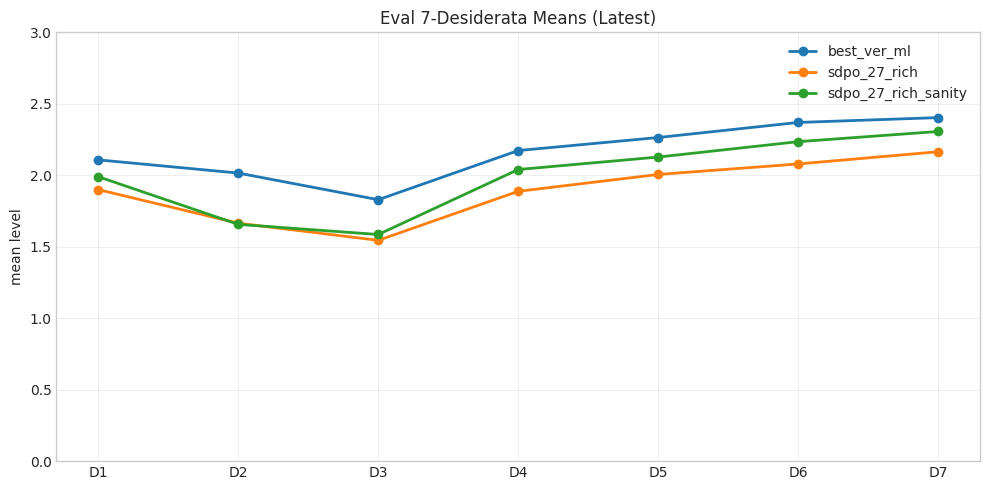

In [6]:
# 3) 7-desiderata decomposition on eval logs (latest)
des_rows = []
for spec in RUNS:
    label = spec['label']
    ref = run_eval_refs[label]['latest_log']
    m = desiderata_metrics(ref)
    rec = {'run': label, 'eval_log_path': str(ref) if ref else ''}
    rec.update(m)
    des_rows.append(rec)

des_df = pd.DataFrame(des_rows)
print('Eval desiderata means (latest):')
display(des_df[['run','des_coverage','des_overall_mean'] + [c for c in [f'd{i}_mean' for i in range(1,8)] if c in des_df.columns]].round(4))

if BASELINE_LABEL not in des_df['run'].tolist():
    raise ValueError('Baseline not present in desiderata table.')

base = des_df[des_df['run'] == BASELINE_LABEL].iloc[0]
delta_rows = []
for _, r in des_df.iterrows():
    if r['run'] == BASELINE_LABEL:
        continue
    rec = {'run': r['run']}
    for i in range(1, 8):
        c = f'd{i}_mean'
        if c in des_df.columns and pd.notna(r.get(c)) and pd.notna(base.get(c)):
            rec[f'delta_{c}'] = float(r[c] - base[c])
    if pd.notna(r.get('d2_mean')) and pd.notna(base.get('d2_mean')):
        rec['gap_to_baseline_d2'] = float(base['d2_mean'] - r['d2_mean'])
        rec['gate_d2_gap'] = 'PASS' if rec['gap_to_baseline_d2'] <= GATE_D2D3_GAP_MAX_TO_BASELINE else 'FAIL'
    else:
        rec['gate_d2_gap'] = 'NA'
    if pd.notna(r.get('d3_mean')) and pd.notna(base.get('d3_mean')):
        rec['gap_to_baseline_d3'] = float(base['d3_mean'] - r['d3_mean'])
        rec['gate_d3_gap'] = 'PASS' if rec['gap_to_baseline_d3'] <= GATE_D2D3_GAP_MAX_TO_BASELINE else 'FAIL'
    else:
        rec['gate_d3_gap'] = 'NA'
    delta_rows.append(rec)

des_delta_df = pd.DataFrame(delta_rows)
print('Desiderata deltas vs baseline (focus on D2/D3):')
display(des_delta_df.round(4))

# quick visual
plot_cols = [f'd{i}_mean' for i in range(1,8) if f'd{i}_mean' in des_df.columns]
if plot_cols:
    fig, ax = plt.subplots(figsize=(10,5))
    x = np.arange(1, len(plot_cols)+1)
    for _, row in des_df.iterrows():
        y = [row[c] for c in plot_cols]
        ax.plot(x, y, marker='o', linewidth=2, label=row['run'])
    ax.set_xticks(x)
    ax.set_xticklabels([f'D{i}' for i in x])
    ax.set_ylim(0, 3)
    ax.set_title('Eval 7-Desiderata Means (Latest)')
    ax.set_ylabel('mean level')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()



In [7]:
# 4) 3-run recovery ladder (A/B/C) as executable override specs + command templates
RECOVERY_BASE_RUN = Path('/home/silas/co-scientist-project/runs/2026/2/SDPO/27(rich)')
RECOVERY_ROOT = Path('/home/silas/co-scientist-project/runs/2026/2/SDPO')

run_specs = {
    'run_A_format_first': {
        'log_path': str(RECOVERY_ROOT / '27_recovery_A'),
        'max_batches': 107,
        'save_every': 10,
        'format_retry_enabled': True,
        'format_retry_max_attempts': 1,
        'format_retry_temperature': 0.3,
        'format_retry_max_tokens': 1024,
        'max_tokens': 1536,
        'use_sdpo': True,
    },
    'run_B_rebalance': {
        'log_path': str(RECOVERY_ROOT / '27_recovery_B'),
        'max_batches': 107,
        'save_every': 10,
        'format_retry_enabled': True,
        'format_retry_max_attempts': 1,
        'format_retry_temperature': 0.3,
        'format_retry_max_tokens': 1024,
        'max_tokens': 1536,
        'use_sdpo': True,
        'sdpo_grpo_mix_lambda': 0.70,
        'sdpo_success_adaptive_quantile': 0.80,
        'sdpo_success_min_rate': 0.10,
        'sdpo_success_floor': 0.55,
        'sdpo_teacher_reg_alpha': 0.0,
    },
    'run_C_winner_full_budget': {
        'log_path': str(RECOVERY_ROOT / '27_recovery_C'),
        'max_batches': 214,
        'save_every': 10,
        # winner settings from A/B should be merged here before launch
    },
}

run_ladder_df = pd.DataFrame([
    {
        'run': k,
        **v,
    }
    for k, v in run_specs.items()
])
print('Recovery ladder run specs:')
display(run_ladder_df)

print('\nPython command template (deterministic override path):')
for run_name, ov in run_specs.items():
    print('\n' + '='*90)
    print(run_name)
    print('conda run -n tinker python - <<\'PY\'')
    print('import asyncio, chz')
    print('from co_scientist.trainers.sdpo.train_sdpo import Config, main')
    print('cfg = chz.replace(Config(),')
    for k,v in ov.items():
        print(f"    {k}={v!r},")
    print(')')
    print('asyncio.run(main(cfg))')
    print('PY')

print('\nSelection checkpoints to evaluate in Run C: [64, 95, 106, 150, 214]')



Recovery ladder run specs:


,run,log_path,max_batches,save_every,format_retry_enabled,format_retry_max_attempts,format_retry_temperature,format_retry_max_tokens,max_tokens,use_sdpo,sdpo_grpo_mix_lambda,sdpo_success_adaptive_quantile,sdpo_success_min_rate,sdpo_success_floor,sdpo_teacher_reg_alpha
0,run_A_format_first,/home/silas/co-scientist-project/runs/2026/2/S...,107,10,True,1.0,0.3,1024.0,1536.0,True,NaN,NaN,NaN,NaN,NaN
1,run_B_rebalance,/home/silas/co-scientist-project/runs/2026/2/S...,107,10,True,1.0,0.3,1024.0,1536.0,True,0.7,0.8,0.1,0.55,0.0
2,run_C_winner_full_budget,/home/silas/co-scientist-project/runs/2026/2/S...,214,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Python command template (deterministic override path):

run_A_format_first
conda run -n tinker python - <<'PY'
import asyncio, chz
from co_scientist.trainers.sdpo.train_sdpo import Config, main
cfg = chz.replace(Config(),
    log_path='/home/silas/co-scientist-project/runs/2026/2/SDPO/27_recovery_A',
    max_batches=107,
    save_every=10,
    format_retry_enabled=True,
    format_retry_max_attempts=1,
    format_retry_temperature=0.3,
    format_retry_max_tokens=1024,
    max_tokens=1536,
    use_sdpo=True,
)
asyncio.run(main(cfg))
PY

run_B_rebalance
conda run -n tinker python - <<'PY'
import asyncio, chz
from co_scientist.trainers.sdpo.train_sdpo import Config, main
cfg = chz.replace(Config(),
    log_path='/home/silas/co-scientist-project/runs/2026/2/SDPO/27_recovery_B',
    max_batches=107,
    save_every=10,
    format_retry_enabled=True,
    format_retry_max_attempts=1,
    format_retry_temperature=0.3,
    format_retry_max_tokens=1024,
    max_tokens=1536,
    use_sdpo=True,
 

In [8]:
# 5) Selection rule checker + test scenarios from plan

def evaluate_checkpoint_set(run_dir: Path, steps: list[int]) -> pd.DataFrame:
    rows = []
    for s in steps:
        logp = select_eval_file(run_dir, 'eval_logs', step=s)
        batchp = paired_eval_batch_summary(run_dir, logp)
        rec = {'run_dir': str(run_dir), 'step': s, 'exists': bool(logp is not None)}
        rec.update(eval_metrics_from_logs(logp))
        rec.update(eval_metrics_from_batch(batchp))
        rows.append(rec)
    return pd.DataFrame(rows)

# Use current SDPO run as demonstration of selection logic (Run C should replace this path).
candidate_run = Path('/home/silas/co-scientist-project/runs/2026/2/SDPO/27(rich)')
candidate_steps = [64, 95, 106, 150, 214]
ckpt_df = evaluate_checkpoint_set(candidate_run, candidate_steps)
print('Checkpoint selection table (demo on current SDPO run):')
display(ckpt_df[['step','exists','eval_rubric_mean','eval_compliance_rate','eval_format_violation_rate','eval_word_p90','eval_log_path']].round(4))

# Rank by primary metric then tie-breakers.
rank_df = ckpt_df.copy()
for c in ['eval_rubric_mean','eval_compliance_rate']:
    rank_df[c] = pd.to_numeric(rank_df[c], errors='coerce')
rank_df['eval_format_violation_rate'] = pd.to_numeric(rank_df['eval_format_violation_rate'], errors='coerce')
rank_df = rank_df[rank_df['exists'] == True]
if not rank_df.empty:
    rank_df = rank_df.sort_values(
        by=['eval_rubric_mean', 'eval_compliance_rate', 'eval_format_violation_rate'],
        ascending=[False, False, True],
    )
print('Primary+tie-break ranking:')
display(rank_df[['step','eval_rubric_mean','eval_compliance_rate','eval_format_violation_rate']].head(10).round(4))

# Test scenarios
scenario_rows = []

# Consistency scenario: ranking under latest vs matched for currently available runs.
for run in policy_df['run'].unique():
    latest = policy_df[(policy_df['run']==run) & (policy_df['policy']=='latest')]
    matched = policy_df[(policy_df['run']==run) & (policy_df['policy']==f'matched_{MATCHED_STEP}')]
    scenario_rows.append({
        'run': run,
        'scenario': 'consistency_latest_vs_matched_available',
        'pass': bool((not latest.empty) and (not matched.empty) and pd.notna(latest.iloc[0].get('eval_rubric_mean')) and pd.notna(matched.iloc[0].get('eval_rubric_mean'))),
    })

# Missing-data scenario
for s in candidate_steps:
    exists = bool(select_eval_file(candidate_run, 'eval_logs', step=s) is not None)
    scenario_rows.append({'run': candidate_run.name, 'scenario': f'missing_data_step_{s}', 'pass': exists})

# Overlength scenario (latest rows)
for _, r in policy_df[policy_df['policy']=='latest'].iterrows():
    p90 = r.get('eval_word_p90', np.nan)
    scenario_rows.append({'run': r['run'], 'scenario': 'overlength_p90<=1200', 'pass': (pd.notna(p90) and p90 <= 1200)})

# SDPO-starvation scenario (latest train check rows)
for _, r in train_check_df.iterrows():
    if r['run'] == BASELINE_LABEL:
        continue
    v = r.get('late_sdpo_success_rate_groups', np.nan)
    scenario_rows.append({'run': r['run'], 'scenario': 'sdpo_success_rate_groups>0.10', 'pass': (pd.notna(v) and v > 0.10)})

# Drift scenario
for _, r in train_check_df.iterrows():
    v = r.get('drift_flag', np.nan)
    scenario_rows.append({'run': r['run'], 'scenario': 'no_late_drift_reward_down_format_up', 'pass': (pd.notna(v) and (not bool(v)))})

scenario_df = pd.DataFrame(scenario_rows)
print('Test scenarios status:')
display(scenario_df)

print('\nAcceptance thresholds for recovered SDPO:')
print(f'- eval rubric mean >= {GATE_RECOVERED_EVAL_RUBRIC_MIN}')
print(f'- compliance >= {GATE_COMPLIANCE_MIN}')
print(f'- format violation <= {GATE_FORMAT_MAX}')
print(f'- |D2 gap to baseline| <= {GATE_D2D3_GAP_MAX_TO_BASELINE}')
print(f'- |D3 gap to baseline| <= {GATE_D2D3_GAP_MAX_TO_BASELINE}')



Checkpoint selection table (demo on current SDPO run):


,step,exists,eval_rubric_mean,eval_compliance_rate,eval_format_violation_rate,eval_word_p90,eval_log_path
0,64,False,NaN,NaN,NaN,NaN,NaN
1,95,False,NaN,NaN,NaN,NaN,NaN
2,106,True,0.5702,0.9255,0.0745,1511.0,/home/silas/co-scientist-project/runs/2026/2/S...
3,150,False,NaN,NaN,NaN,NaN,NaN
4,214,False,NaN,NaN,NaN,NaN,NaN


Primary+tie-break ranking:


,step,eval_rubric_mean,eval_compliance_rate,eval_format_violation_rate
2,106,0.5702,0.9255,0.0745


Test scenarios status:


,run,scenario,pass
0,best_ver_ml,consistency_latest_vs_matched_available,False
1,sdpo_27_rich,consistency_latest_vs_matched_available,True
2,sdpo_27_rich_sanity,consistency_latest_vs_matched_available,True
3,27(rich),missing_data_step_64,False
4,27(rich),missing_data_step_95,False
5,27(rich),missing_data_step_106,True
6,27(rich),missing_data_step_150,False
7,27(rich),missing_data_step_214,False
8,best_ver_ml,overlength_p90<=1200,True
9,sdpo_27_rich,overlength_p90<=1200,False



Acceptance thresholds for recovered SDPO:
- eval rubric mean >= 0.67
- compliance >= 0.97
- format violation <= 0.03
- |D2 gap to baseline| <= 0.1
- |D3 gap to baseline| <= 0.1


## Usage

1. Update `RUNS` and checkpoint steps in the config cell.
2. Run all cells top-to-bottom.
3. Use sections in this order: protocol table -> failure gates -> desiderata deltas -> run ladder -> selection tests.
4. For Run C, replace `candidate_run` with your new run folder and re-run selection + scenario cells.
